# ILUSTR 3 (DODATEK, opcjonalny) — skąd bierze się skok dokładności biblioteczne QR przy n≈128?

**Ten notebook jest materiałem opcjonalnym**, nie częścią podstawowego kursu. Główny notebook `ZI_R_LIN_ILUSTR3_PYTHON.ipynb` (Demo 1, LU vs QR na macierzy Lehmera) celowo używa **własnej**, prostej implementacji QR zamiast wbudowanej `np.linalg.qr` — żeby wykres pokazywał czysty, łagodny wzrost błędu bez dodatkowych efektów. Tutaj sprawdzamy, co by się stało, gdybyśmy jednak użyli biblioteki: **wbudowane `np.linalg.qr` staje się nagle kilka razy mniej dokładne względem LU dokładnie w okolicy $n=128$** — badamy dlaczego, porównując je z własną implementacją.

**Wniosek z góry** (żeby wiedzieć, czego szukać): to nie jest właściwość matematyki algorytmu Householdera — to artefakt konkretnej biblioteki numerycznej (LAPACK), która powyżej pewnego rozmiaru macierzy przełącza się na szybszy, ale nieco mniej dokładny wariant blokowany.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

EPS = np.finfo(np.float64).eps


def lehmer(n):
    i = np.arange(1, n + 1).reshape(-1, 1)
    j = np.arange(1, n + 1).reshape(1, -1)
    return np.minimum(i, j) / np.maximum(i, j)


## Własna, nieblokowana implementacja QR

Piszemy QR "na piechotę" (jedno odbicie Householdera na raz), bo biblioteczne `np.linalg.qr` powyżej pewnego rozmiaru macierzy automatycznie przełącza się wewnątrz LAPACK na wersję **blokowaną** (kilka odbić naraz, szybszą na cache procesora) — a to zmienia rozkład błędów zaokrągleń. Własna wersja pozwala zobaczyć "czysty" efekt matematyczny algorytmu, bez tego dodatkowego, zależnego od biblioteki zachowania.


In [2]:
def qr_householder_wlasny(A):
    A = A.copy()
    n = A.shape[0]
    Q = np.eye(n)
    for k in range(n - 1):
        x = A[k:, k]
        alpha = -np.sign(x[0]) * np.linalg.norm(x) if x[0] != 0 else -np.linalg.norm(x)
        v = x.copy()
        v[0] -= alpha
        vnorm = np.linalg.norm(v)
        if vnorm < 1e-300:
            continue
        v = v / vnorm
        A[k:, k:] -= 2.0 * np.outer(v, v @ A[k:, k:])
        Q[k:, :] -= 2.0 * np.outer(v, v @ Q[k:, :])
    return Q.T, np.triu(A)


## Porównanie: reszta QR/LU, LAPACK vs własna implementacja

Miarą jest reszta $\|A\hat{x}-b\|/(\|A\|\|x\|)$ — błąd wsteczny, niezależny od $cond(A)$ (w przeciwieństwie do błędu względem znanego rozwiązania), więc dobrze izoluje efekt samego algorytmu od uwarunkowania zadania. Własna implementacja jest $O(n^3)$ bez optymalizacji BLAS-owych (pojedyncze wywołanie dla $n=1000$ trwa ~5s), więc ograniczamy się do $n\le1000$ i 10 powtórzeń na punkt.


In [3]:
rozmiary = [64, 100, 128, 140, 160, 200, 500, 1000]
POWTORZENIA = 10

stosunki_lapack = np.empty(len(rozmiary))
stosunki_wlasny = np.empty(len(rozmiary))

print(f"{'n':>6}  {'reszta QR(LAPACK)/LU':>21}  {'reszta QR(wlasny)/LU':>21}")
for k, n in enumerate(rozmiary):
    A = lehmer(n)
    r_lu, r_lapack, r_wlasny = [], [], []
    for seed in range(POWTORZENIA):
        rng = np.random.default_rng(seed)
        x_prawdziwe = rng.standard_normal(n)
        b = A @ x_prawdziwe

        x_lu = np.linalg.solve(A, b)
        Q1, R1 = np.linalg.qr(A)                          # wbudowane, LAPACK
        x_qr_lapack = solve_triangular(R1, Q1.T @ b)
        Q2, R2 = qr_householder_wlasny(A)                  # wlasne, nieblokowane
        x_qr_wlasny = solve_triangular(R2, Q2.T @ b)

        r_lu.append(np.linalg.norm(A @ x_lu - b) / (np.linalg.norm(A) * np.linalg.norm(x_lu)))
        r_lapack.append(np.linalg.norm(A @ x_qr_lapack - b) / (np.linalg.norm(A) * np.linalg.norm(x_qr_lapack)))
        r_wlasny.append(np.linalg.norm(A @ x_qr_wlasny - b) / (np.linalg.norm(A) * np.linalg.norm(x_qr_wlasny)))

    r_lu_med = np.median(r_lu)
    stosunki_lapack[k] = np.median(r_lapack) / r_lu_med
    stosunki_wlasny[k] = np.median(r_wlasny) / r_lu_med
    print(f"{n:6d}  {stosunki_lapack[k]:21.2f}  {stosunki_wlasny[k]:21.2f}")


     n   reszta QR(LAPACK)/LU   reszta QR(wlasny)/LU
    64                   1.23                   1.73


   100                   1.42                   1.86


   128                   1.46                   2.11


   140                   6.03                   2.25


   160                   5.82                   2.50


   200                   6.78                   2.34


   500                   5.34                   3.58


  1000                   5.63                   5.30


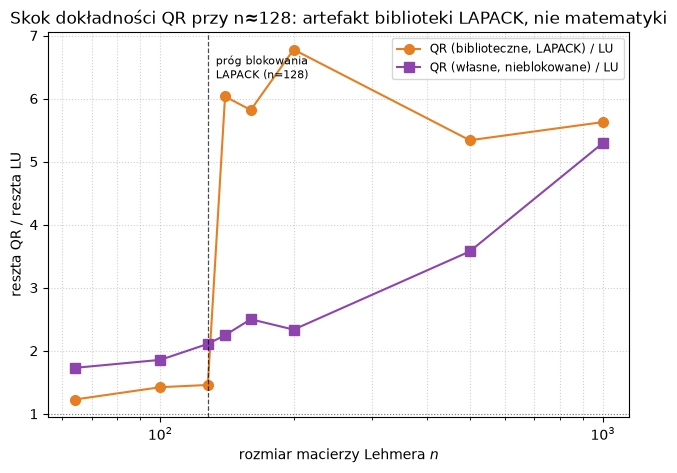

In [4]:
plt.figure(figsize=(7.5, 5))
plt.semilogx(rozmiary, stosunki_lapack, 'o-', color='#e67e22', markersize=7,
             label='QR (biblioteczne, LAPACK) / LU')
plt.semilogx(rozmiary, stosunki_wlasny, 's-', color='#8e44ad', markersize=7,
             label='QR (własne, nieblokowane) / LU')
plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
plt.axvline(128, color='black', linewidth=0.9, linestyle='--', alpha=0.7)
plt.text(128, plt.ylim()[1] * 0.95, '  próg blokowania\n  LAPACK (n=128)', fontsize=8, va='top')
plt.xlabel('rozmiar macierzy Lehmera $n$')
plt.ylabel('reszta QR / reszta LU')
plt.title('Skok dokładności QR przy n≈128: artefakt biblioteki LAPACK, nie matematyki')
plt.legend(fontsize=8.5)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()


## Interpretacja

Widać dwa nakładające się zjawiska:

1. **Prawdziwa, matematyczna różnica** (fioletowa krzywa, własna implementacja) — rośnie z $n$ gładko, bez żadnego skoku: rozwiązanie przez QR wymaga, oprócz samego rozkładu, przemnożenia $Q^Tb$ ($n$ odbić Householdera zastosowanych po kolei) i dopiero potem podstawienia wstecznego z $R$, podczas gdy LU kończy jedną parą podstawień trójkątnych zaraz po eliminacji. Każdy dodatkowy krok wnosi swoją, małą porcję błędu zaokrąglenia, a przy rosnącym $n$ tych kroków przybywa — stąd narost, ale bez skoku.

2. **Artefakt implementacji biblioteki** (pomarańczowa krzywa, `np.linalg.qr`) — dokładnie przy $n=128$ (pionowa przerywana linia) skacze skokowo, podczas gdy własna wersja w tym samym miejscu zmienia się tylko nieznacznie. To sygnatura przełączenia LAPACK z liczenia odbić Householdera pojedynczo na wersję **blokowaną** (reprezentacja WY, kilka odbić naraz, szybszą dzięki lepszemu wykorzystaniu cache procesora) — matematycznie równoważną, ale z innym rozkładem błędów zaokrągleń. Ciekawe, że przy jeszcze większych $n$ (500-1000) różnica między wersją biblioteczną a własną znów się zmniejsza — bo gładki wzrost błędu własnej wersji z czasem "dogania" wczesny skok biblioteki. To sam **skok** (a nie ostateczna wartość przy dużym $n$), jest więc czystą sygnaturą efektu implementacyjnego, nie matematyki algorytmu.

**Zastrzeżenie**: próg $n=128$ i skala skoku zmierzono dla konkretnej biblioteki BLAS/LAPACK (NumPy/OpenBLAS) w tym środowisku. Inna biblioteka (MKL, inny dostawca) może pokazać skok w innym miejscu, o innej skali, albo wcale — `ZI_R_LIN_ILUSTR3.m` zawiera tę samą własną implementację QR (funkcja `qr_householder_wlasny`) do sprawdzenia w MATLAB-ie.

## Praktyczny wniosek

Zmierzony błąd numeryczny zależy nie tylko od matematyki algorytmu, ale też od konkretnej implementacji biblioteki, z której korzystamy — coś, co rzadko widać w podręcznikowych oszacowaniach teoretycznych, a co realnie wpływa na wyniki w praktyce inżynierskiej. Pełny opis diagnozy (łącznie z odrzuconymi po drodze hipotezami) jest w `_doc/2026-09-07_LU_vs_QR_dokladnosc_Lehmer.md` w katalogu głównym repozytorium.
